In [82]:
import pandas as pd

df = pd.read_csv("/content/diabetes.csv")

print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2            8      183           64.0             32    169.5  23.3   
3            1       89           66.0             23     94.0  28.1   
4            0      137           40.0             35    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [83]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
print(df.describe())

Dataset Shape:
(768, 9)

Column Names:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure               float64
SkinThickness                 int64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    i

In [84]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [85]:
print("Number of duplicate rows:")
print(df.duplicated().sum())

df = df.drop_duplicates()

print("Shape after removing duplicates:")
print(df.shape)

Number of duplicate rows:
0
Shape after removing duplicates:
(768, 9)


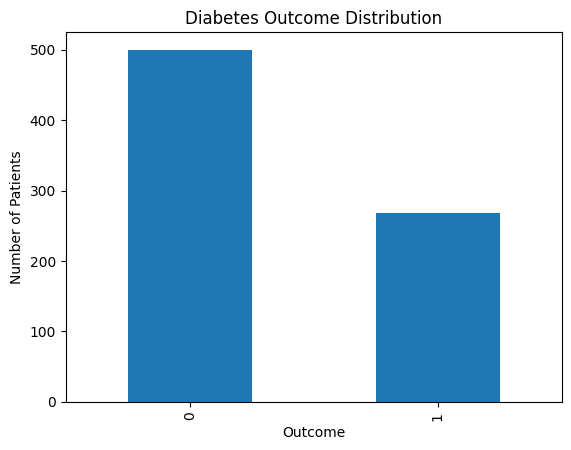

In [86]:
import matplotlib.pyplot as plt

df["Outcome"].value_counts().plot(kind="bar")

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")
plt.show()

In [87]:
from scipy.stats import ttest_ind

diabetic = df[df["Outcome"] == 1]["Glucose"]

non_diabetic = df[df["Outcome"] == 0]["Glucose"]

t_stat, p_value = ttest_ind(
    diabetic,
    non_diabetic,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0: Significant difference exists.")
else:
    print("Fail to reject H0: No significant difference.")

T-statistic: 14.992112521284485
P-value: 8.301766379086572e-42
Reject H0: Significant difference exists.


In [89]:
from scipy.stats import chi2_contingency

df["Glucose_Category"] = pd.cut(
    df["Glucose"],
    bins=[0, 99, 125, 200],
    labels=["Normal", "Prediabetes", "High"]
)

table = pd.crosstab(
    df["Glucose_Category"],
    df["Outcome"]
)

print("Contingency Table:")
print(table)

chi2, p_value, dof, expected = chi2_contingency(table)

print("\nChi-square:", chi2)
print("P-value:", p_value)
print("Degrees of freedom:", dof)

if p_value < 0.05:
    print("Reject H0: Significant association exists.")
else:
    print("Fail to reject H0: No significant association exists.")

Contingency Table:
Outcome             0    1
Glucose_Category          
Normal            178   14
Prediabetes       201   76
High              121  178

Chi-square: 151.05894757837294
P-value: 1.577488901039001e-33
Degrees of freedom: 2
Reject H0: Significant association exists.


In [90]:
from scipy.stats import f_oneway

normal = df[df["Glucose_Category"] == "Normal"]["Glucose"]
prediabetes = df[df["Glucose_Category"] == "Prediabetes"]["Glucose"]
high = df[df["Glucose_Category"] == "High"]["Glucose"]

f_stat, p_value = f_oneway(normal, prediabetes, high)

print("F-statistic:", f_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0: Significant difference exists between groups.")
else:
    print("Fail to reject H0: No significant difference between groups.")

F-statistic: 1303.0248499407257
P-value: 4.269008230881381e-247
Reject H0: Significant difference exists between groups.


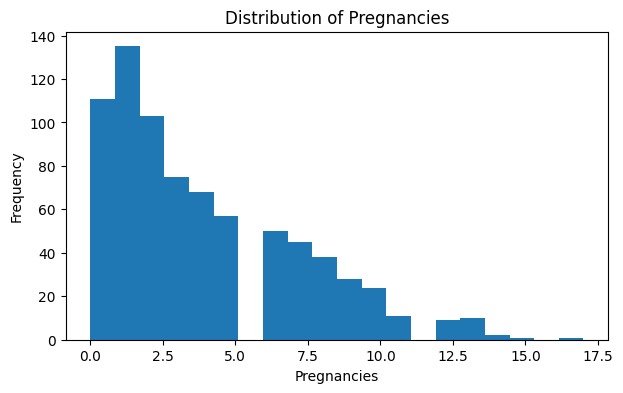

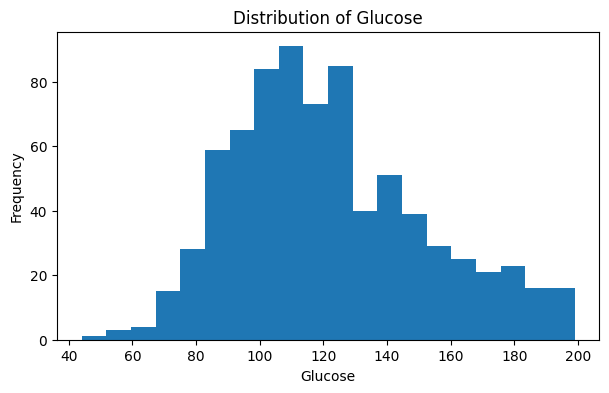

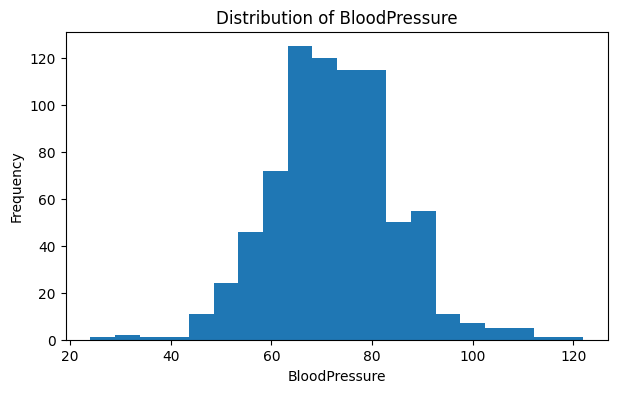

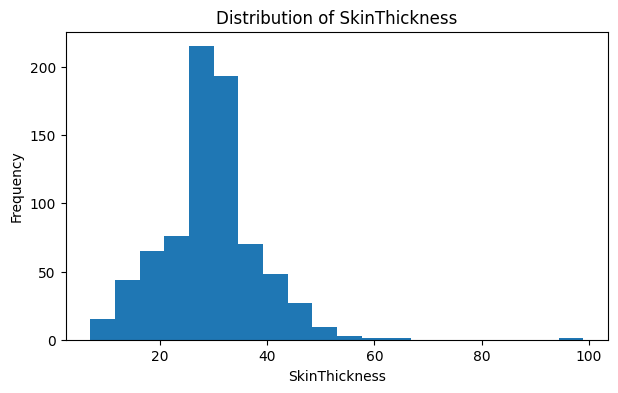

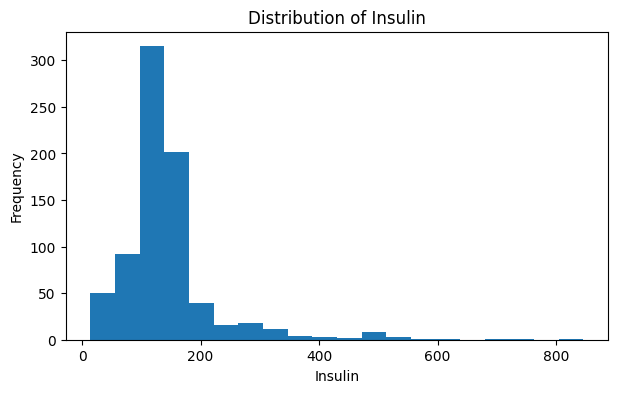

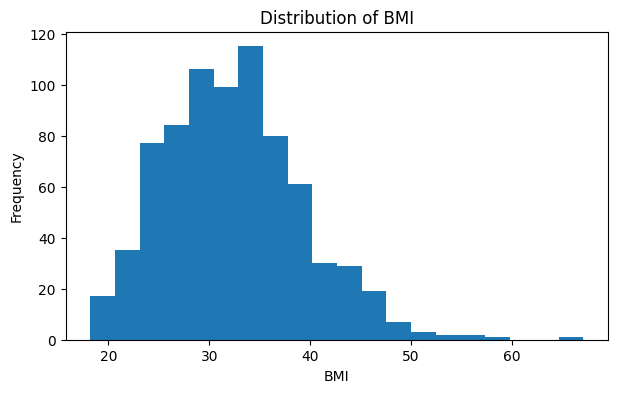

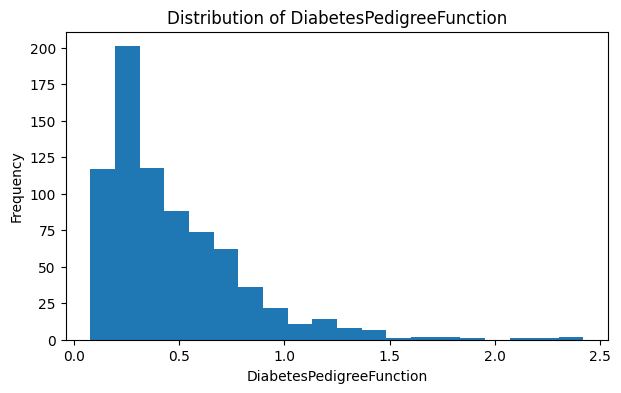

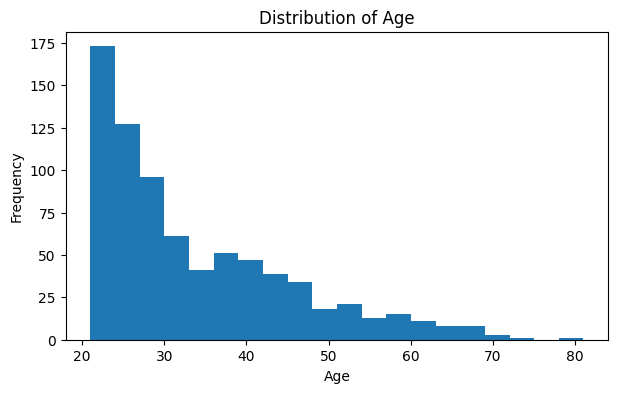

In [91]:
import matplotlib.pyplot as plt

numeric_columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

for column in numeric_columns:
    plt.figure(figsize=(7, 4))
    plt.hist(df[column], bins=20)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

In [92]:

df["BMI_Category"] = pd.cut(
    df["BMI"],
    bins=[0, 18.5, 25, 30, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

print(df[["BMI", "BMI_Category"]].head())

    BMI BMI_Category
0  33.6        Obese
1  26.6   Overweight
2  23.3       Normal
3  28.1   Overweight
4  43.1        Obese


In [93]:

correlation = df.corr(numeric_only=True)["Outcome"].sort_values(ascending=False)

print("Correlation with Outcome:")
print(correlation)

Correlation with Outcome:
Outcome                     1.000000
Glucose                     0.495990
Insulin                     0.377081
BMI                         0.315577
SkinThickness               0.295138
Age                         0.238356
Pregnancies                 0.221898
BloodPressure               0.174469
DiabetesPedigreeFunction    0.173844
Name: Outcome, dtype: float64


In [96]:
import numpy as np
features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

X = df[features]
X = df[features].copy()

X_augmented = X + np.random.normal(
    loc=0,
    scale=0.01,
    size=X.shape
)

print("Original data:")
print(X.head())

print("\nAugmented data:")
print(X_augmented.head())

Original data:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2            8      183           64.0             32    169.5  23.3   
3            1       89           66.0             23     94.0  28.1   
4            0      137           40.0             35    168.0  43.1   

   DiabetesPedigreeFunction  Age  
0                     0.627   50  
1                     0.351   31  
2                     0.672   32  
3                     0.167   21  
4                     2.288   33  

Augmented data:
   Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
0     5.991185  148.003992      71.988159      34.999931  169.500901   
1     1.007675   84.993356      65.991879      28.989791  102.502454   
2     7.991385  183.014251      63.995342      32.005212  169.498240   
3     1.009744   88.996528      66.00

In [99]:
import pandas as pd

df_text = pd.read_csv("/content/mtsamples.csv")

print(df_text.head())

   Unnamed: 0                                        description  \
0           0   A 23-year-old white female presents with comp...   
1           1           Consult for laparoscopic gastric bypass.   
2           2           Consult for laparoscopic gastric bypass.   
3           3                             2-D M-Mode. Doppler.     
4           4                                 2-D Echocardiogram   

             medical_specialty                                sample_name  \
0         Allergy / Immunology                         Allergic Rhinitis    
1                   Bariatrics   Laparoscopic Gastric Bypass Consult - 2    
2                   Bariatrics   Laparoscopic Gastric Bypass Consult - 1    
3   Cardiovascular / Pulmonary                    2-D Echocardiogram - 1    
4   Cardiovascular / Pulmonary                    2-D Echocardiogram - 2    

                                       transcription  \
0  SUBJECTIVE:,  This 23-year-old white female pr...   
1  PAST MEDICAL 

In [100]:
print("Dataset shape:", df_text.shape)

print("\nColumn names:")
print(df_text.columns.tolist())

print("\nFirst 5 medical transcriptions:")
print(df_text["transcription"].head())

Dataset shape: (4999, 6)

Column names:
['Unnamed: 0', 'description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']

First 5 medical transcriptions:
0    SUBJECTIVE:,  This 23-year-old white female pr...
1    PAST MEDICAL HISTORY:, He has difficulty climb...
2    HISTORY OF PRESENT ILLNESS: , I have seen ABC ...
3    2-D M-MODE: , ,1.  Left atrial enlargement wit...
4    1.  The left ventricular cavity size and wall ...
Name: transcription, dtype: object


In [101]:
print("Missing values:")
print(df_text.isnull().sum())

Missing values:
Unnamed: 0              0
description             0
medical_specialty       0
sample_name             0
transcription          33
keywords             1068
dtype: int64


In [102]:
df_text = df_text.drop(columns=["Unnamed: 0"])

print(df_text.columns.tolist())

['description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']


In [103]:
text_columns = [
    "description",
    "medical_specialty",
    "sample_name",
    "transcription",
    "keywords"
]

for column in text_columns:
    df_text[column] = df_text[column].fillna("")

print(df_text.isnull().sum())

description          0
medical_specialty    0
sample_name          0
transcription        0
keywords             0
dtype: int64


In [104]:
import re

def clean_text(text):
    text = str(text)

    text = text.lower()

    text = re.sub(r"\s+", " ", text)

    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)

    return text.strip()

df_text["cleaned_text"] = df_text["transcription"].apply(clean_text)

print(df_text[["transcription", "cleaned_text"]].head())

                                       transcription  \
0  SUBJECTIVE:,  This 23-year-old white female pr...   
1  PAST MEDICAL HISTORY:, He has difficulty climb...   
2  HISTORY OF PRESENT ILLNESS: , I have seen ABC ...   
3  2-D M-MODE: , ,1.  Left atrial enlargement wit...   
4  1.  The left ventricular cavity size and wall ...   

                                        cleaned_text  
0  subjective this 23yearold white female present...  
1  past medical history he has difficulty climbin...  
2  history of present illness  i have seen abc to...  
3  2d mmode  1 left atrial enlargement with left ...  
4  1 the left ventricular cavity size and wall th...  


In [105]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer()

tokenizer.fit_on_texts(df_text["transcription"])

sequences = tokenizer.texts_to_sequences(df_text["transcription"])

print("First 5 token sequences:")
for sequence in sequences[:5]:
    print(sequence)

First 5 token sequences:
[1159, 17, 1204, 74, 76, 293, 204, 661, 7, 489, 4, 207, 12, 71, 5, 52, 207, 212, 12, 5538, 8, 10126, 58, 12, 3016, 258, 45, 1038, 652, 8, 1, 90, 12, 22, 1927, 3813, 2, 3676, 132, 1705, 13, 820, 57, 58, 19, 1891, 5, 3954, 10928, 12, 22, 71, 3867, 56, 12, 71, 25, 254, 5660, 2, 12, 789, 59, 50, 217, 94, 282, 300, 50, 107, 39, 778, 5, 33, 1402, 154, 41, 12, 22, 71, 88, 1, 2780, 5661, 58, 11, 1269, 337, 5661, 12, 107, 52, 1373, 58, 16775, 39, 1822, 161, 590, 13, 17, 2, 107, 39, 1073, 50, 9, 8173, 85, 115, 26, 395, 590, 429, 9, 6925, 9681, 10929, 2, 1, 3867, 207, 12, 22, 11, 523, 2102, 207, 1528, 2482, 246, 3, 2573, 521, 2, 62, 111, 4895, 2220, 369, 26, 680, 3, 1270, 4123, 67, 2297, 337, 611, 3, 4123, 2, 2814, 395, 127, 821, 3, 153, 1872, 15, 127, 102, 608, 67, 1031, 430, 127, 390, 1284, 2610, 173, 28, 12, 61, 1618, 3676, 4227, 4, 3867, 217, 1021, 3193, 61, 33, 5, 228, 10127, 12, 107, 39, 1073, 12, 22, 1269, 4033, 318, 25, 1846, 33, 16776, 27, 3497, 4, 8174, 94, 5661

In [106]:
import matplotlib.pyplot as plt

specialty_counts = df_text["medical_specialty"].value_counts()

print(specialty_counts)

medical_specialty
Surgery                          1103
Consult - History and Phy.        516
Cardiovascular / Pulmonary        372
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  230
Neurology                         223
SOAP / Chart / Progress Notes     166
Obstetrics / Gynecology           160
Urology                           158
Discharge Summary                 108
ENT - Otolaryngology               98
Neurosurgery                       94
Hematology - Oncology              90
Ophthalmology                      83
Nephrology                         81
Emergency Room Reports             75
Pediatrics - Neonatal              70
Pain Management                    62
Psychiatry / Psychology            53
Office Notes                       51
Podiatry                           47
Dermatology                        29
Dentistry                          27
Cosmetic / Plastic Surgery      

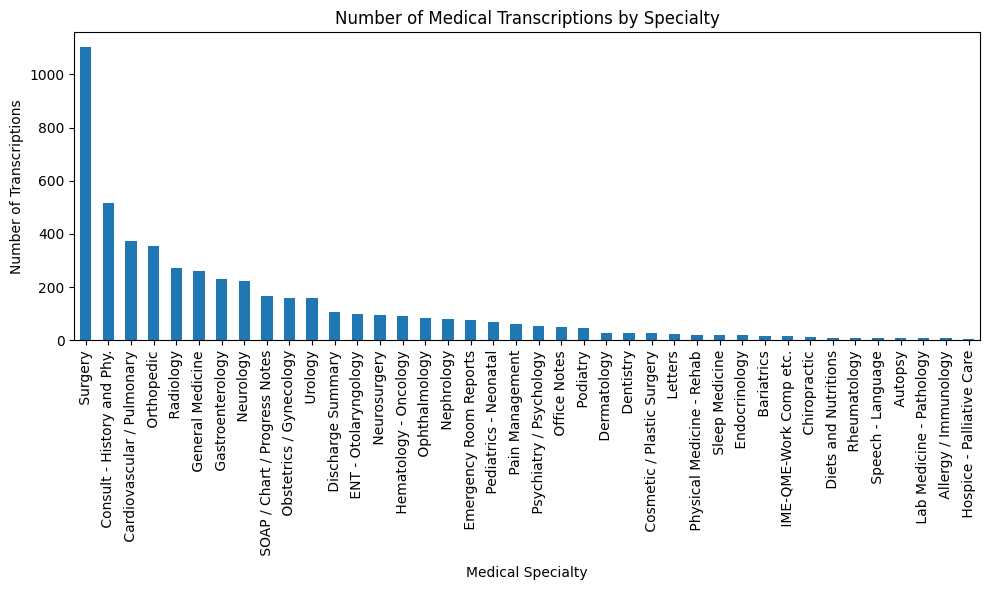

In [107]:
plt.figure(figsize=(10, 6))

specialty_counts.plot(kind="bar")

plt.title("Number of Medical Transcriptions by Specialty")
plt.xlabel("Medical Specialty")
plt.ylabel("Number of Transcriptions")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [108]:

df_text["word_count"] = df_text["transcription"].str.split().str.len()

print(df_text[["transcription", "word_count"]].head())

                                       transcription  word_count
0  SUBJECTIVE:,  This 23-year-old white female pr...         204
1  PAST MEDICAL HISTORY:, He has difficulty climb...         350
2  HISTORY OF PRESENT ILLNESS: , I have seen ABC ...         716
3  2-D M-MODE: , ,1.  Left atrial enlargement wit...          68
4  1.  The left ventricular cavity size and wall ...         229


In [109]:
import re

df_text["cleaned_text"] = df_text["transcription"].apply(
    lambda text: re.sub(r"[^a-zA-Z0-9\s]", "", str(text))
)

df_text["cleaned_text"] = df_text["cleaned_text"].str.replace(
    r"\s+", " ", regex=True
).str.strip()

print(df_text[["transcription", "cleaned_text"]].head())

                                       transcription  \
0  SUBJECTIVE:,  This 23-year-old white female pr...   
1  PAST MEDICAL HISTORY:, He has difficulty climb...   
2  HISTORY OF PRESENT ILLNESS: , I have seen ABC ...   
3  2-D M-MODE: , ,1.  Left atrial enlargement wit...   
4  1.  The left ventricular cavity size and wall ...   

                                        cleaned_text  
0  SUBJECTIVE This 23yearold white female present...  
1  PAST MEDICAL HISTORY He has difficulty climbin...  
2  HISTORY OF PRESENT ILLNESS I have seen ABC tod...  
3  2D MMODE 1 Left atrial enlargement with left a...  
4  1 The left ventricular cavity size and wall th...  


In [110]:

df_augmented = df_text.copy()

df_augmented["augmented_text"] = (
    df_augmented["cleaned_text"]
    .str.replace("  ", " ", regex=False)
)

print(df_augmented[["cleaned_text", "augmented_text"]].head())

                                        cleaned_text  \
0  SUBJECTIVE This 23yearold white female present...   
1  PAST MEDICAL HISTORY He has difficulty climbin...   
2  HISTORY OF PRESENT ILLNESS I have seen ABC tod...   
3  2D MMODE 1 Left atrial enlargement with left a...   
4  1 The left ventricular cavity size and wall th...   

                                      augmented_text  
0  SUBJECTIVE This 23yearold white female present...  
1  PAST MEDICAL HISTORY He has difficulty climbin...  
2  HISTORY OF PRESENT ILLNESS I have seen ABC tod...  
3  2D MMODE 1 Left atrial enlargement with left a...  
4  1 The left ventricular cavity size and wall th...  


In [111]:
import kagglehub

path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

100%|██████████| 2.29G/2.29G [01:38<00:00, 25.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2


In [113]:
import os

print("Dataset contents:")
print(os.listdir(path))

Dataset contents:
['chest_xray']


In [114]:
for item in os.listdir(path):
    item_path = os.path.join(path, item)

    if os.path.isdir(item_path):
        print("\nFolder:", item)
        print("Contents:", os.listdir(item_path))


Folder: chest_xray
Contents: ['test', 'val', '__MACOSX', 'chest_xray', 'train']


In [115]:
import os


train_path = os.path.join(path, "chest_xray", "train")
test_path = os.path.join(path, "chest_xray", "test")
val_path = os.path.join(path, "chest_xray", "val")
print("Training classes:")
print(os.listdir(train_path))

print("\nTesting classes:")
print(os.listdir(test_path))

print("\nValidation classes:")
print(os.listdir(val_path))

Training classes:
['NORMAL', 'PNEUMONIA']

Testing classes:
['NORMAL', 'PNEUMONIA']

Validation classes:
['NORMAL', 'PNEUMONIA']


In [116]:
for folder_name, folder_path in [
    ("Train", train_path),
    ("Test", test_path),
    ("Validation", val_path)
]:

    print(f"\n{folder_name}:")

    for class_name in os.listdir(folder_path):
        class_path = os.path.join(folder_path, class_name)

        if os.path.isdir(class_path):
            print(class_name, ":", len(os.listdir(class_path)), "images")


Train:
NORMAL : 1341 images
PNEUMONIA : 3875 images

Test:
NORMAL : 234 images
PNEUMONIA : 390 images

Validation:
NORMAL : 8 images
PNEUMONIA : 8 images


In [117]:
import tensorflow as tf

IMG_SIZE = (224, 224)

train_data = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=32,
    label_mode="binary"
)

print("Images converted into model-ready format.")
print("Class names:", train_data.class_names)

Found 5216 files belonging to 2 classes.
Images converted into model-ready format.
Class names: ['NORMAL', 'PNEUMONIA']


In [118]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_data = train_data.map(
    lambda images, labels: (normalization_layer(images), labels)
)

print("Image preprocessing completed.")

Image preprocessing completed.


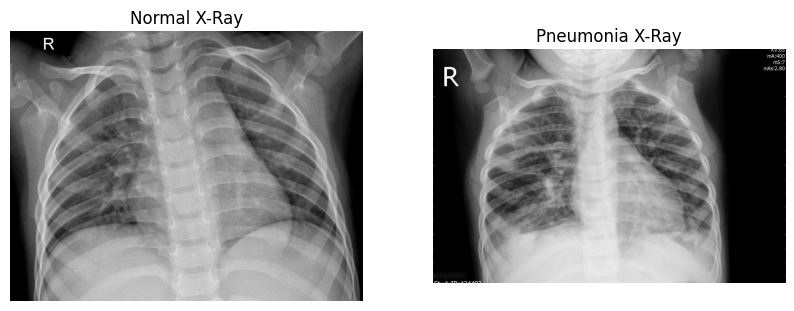

In [119]:
import matplotlib.pyplot as plt
from PIL import Image
import os

normal_image = os.path.join(
    train_path, "NORMAL", os.listdir(os.path.join(train_path, "NORMAL"))[0]
)

pneumonia_image = os.path.join(
    train_path, "PNEUMONIA", os.listdir(os.path.join(train_path, "PNEUMONIA"))[0]
)

normal = Image.open(normal_image)
pneumonia = Image.open(pneumonia_image)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(normal, cmap="gray")
plt.title("Normal X-Ray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(pneumonia, cmap="gray")
plt.title("Pneumonia X-Ray")
plt.axis("off")

plt.show()

In [120]:
from PIL import Image
import os

cleaned_path = os.path.join(path, "cleaned_images")
os.makedirs(cleaned_path, exist_ok=True)

image_file = os.path.join(
    train_path,
    "NORMAL",
    os.listdir(os.path.join(train_path, "NORMAL"))[0]
)

img = Image.open(image_file)

clean_img = Image.new(img.mode, img.size)
clean_img.putdata(list(img.getdata()))

output_file = os.path.join(cleaned_path, "cleaned_xray.jpg")
clean_img.save(output_file)

print("Cleaned image saved successfully.")
print("Original image:", image_file)
print("Cleaned image:", output_file)

Cleaned image saved successfully.
Original image: /root/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2/chest_xray/train/NORMAL/NORMAL2-IM-0389-0001.jpeg
Cleaned image: /root/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2/cleaned_images/cleaned_xray.jpg


In [121]:
import tensorflow as tf

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

augmented_train_data = train_data.map(
    lambda images, labels: (data_augmentation(images, training=True), labels)
)

print("Image augmentation completed.")

Image augmentation completed.


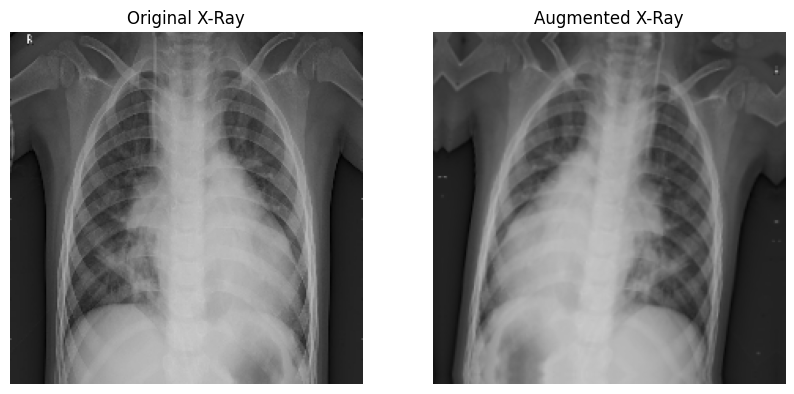

In [122]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_data))

augmented_images = data_augmentation(images, training=True)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(images[0].numpy())
plt.title("Original X-Ray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(augmented_images[0].numpy())
plt.title("Augmented X-Ray")
plt.axis("off")

plt.show()

In [124]:
!pip install wfdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 1.5 MB/s eta 0:00:00


In [125]:
import wfdb

wfdb.dl_database(
    "mitdb",
    dl_dir="/content/mitdb"
)

print("MIT-BIH Arrhythmia Database downloaded successfully.")

Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Generating record list for: 208
Generating record list for: 209
Generati

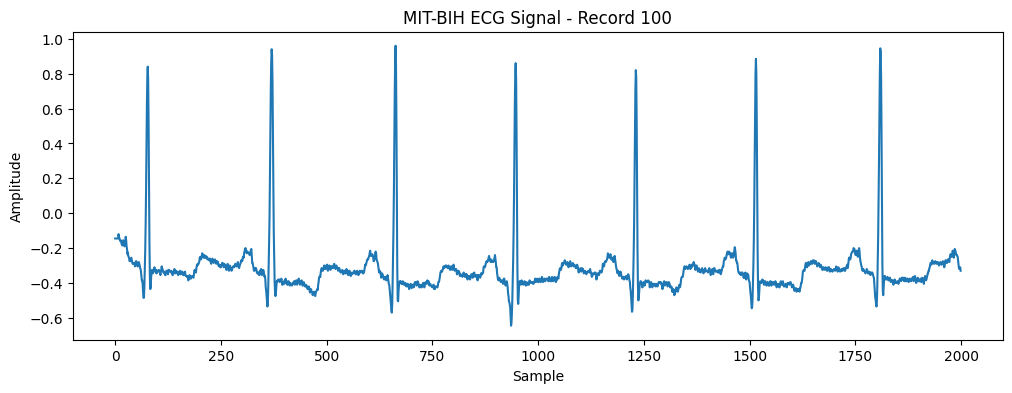

In [126]:
import wfdb
import matplotlib.pyplot as plt

record = wfdb.rdrecord("/content/mitdb/100")

signal = record.p_signal[:, 0]

plt.figure(figsize=(12, 4))
plt.plot(signal[:2000])

plt.title("MIT-BIH ECG Signal - Record 100")
plt.xlabel("Sample")
plt.ylabel("Amplitude")

plt.show()

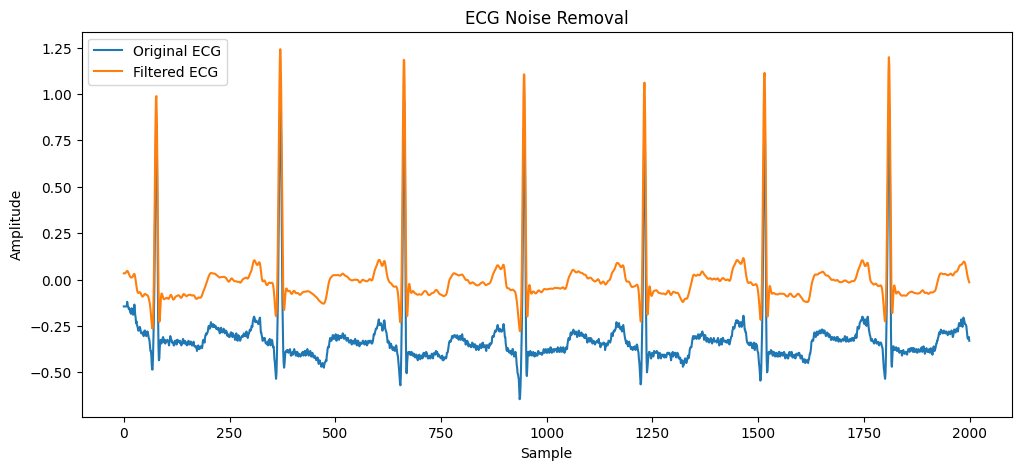

In [127]:

from scipy.signal import butter, filtfilt

signal = record.p_signal[:, 0]

fs = record.fs

lowcut = 0.5
highcut = 40

b, a = butter(
    4,
    [lowcut / (fs / 2), highcut / (fs / 2)],
    btype="band"
)

filtered_signal = filtfilt(b, a, signal)

plt.figure(figsize=(12, 5))

plt.plot(signal[:2000], label="Original ECG")
plt.plot(filtered_signal[:2000], label="Filtered ECG")

plt.title("ECG Noise Removal")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.legend()

plt.show()

In [128]:

signal = filtered_signal

window_size = 500

windows = []

for i in range(0, len(signal) - window_size + 1, window_size):
    window = signal[i:i + window_size]
    windows.append(window)

windows = np.array(windows)

print("Signal windows shape:", windows.shape)
print("Number of windows:", len(windows))
print("Samples in each window:", window_size)

Signal windows shape: (1300, 500)
Number of windows: 1300
Samples in each window: 500


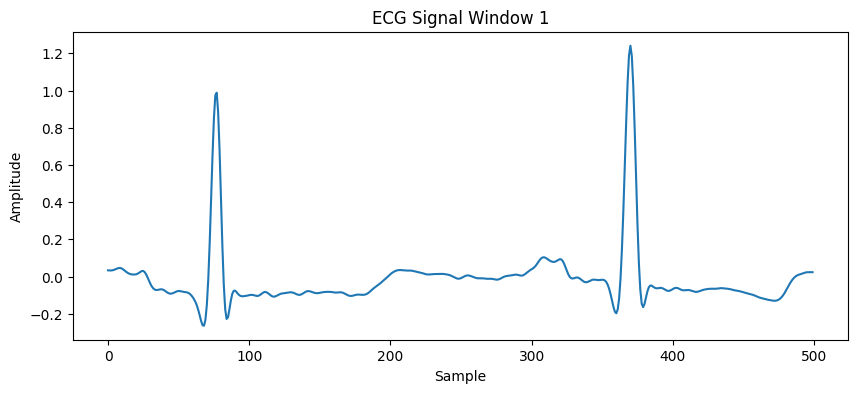

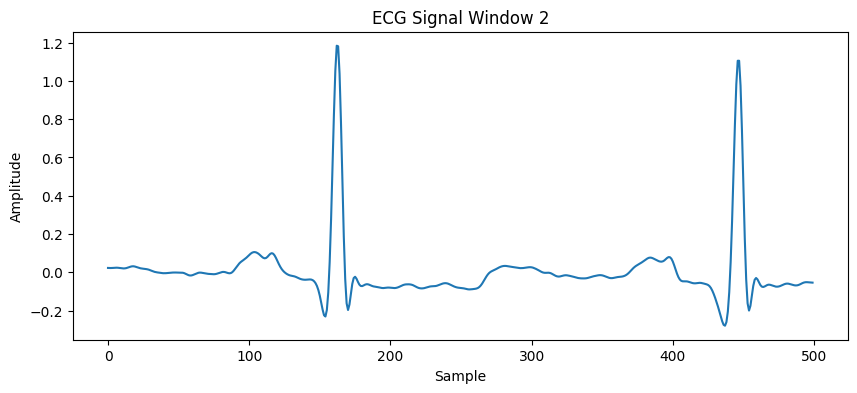

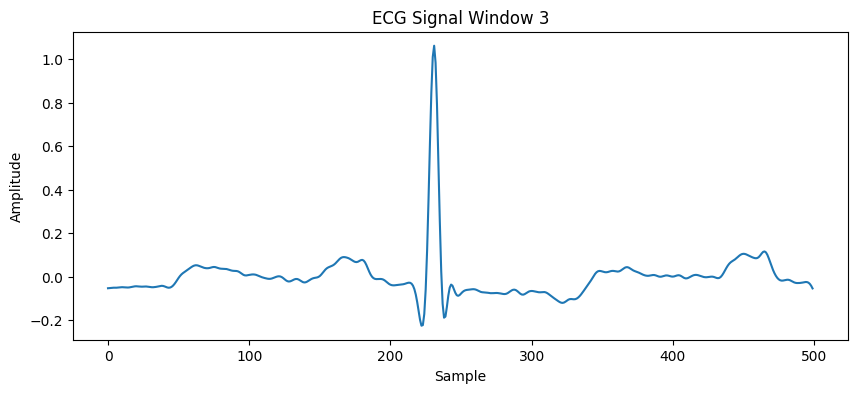

In [129]:
import matplotlib.pyplot as plt

for i in range(3):
    plt.figure(figsize=(10, 4))
    plt.plot(windows[i])

    plt.title(f"ECG Signal Window {i + 1}")
    plt.xlabel("Sample")
    plt.ylabel("Amplitude")

    plt.show()

In [130]:

ecg_features = pd.DataFrame({
    "Mean": np.mean(windows, axis=1),
    "Standard_Deviation": np.std(windows, axis=1),
    "Maximum": np.max(windows, axis=1),
    "Minimum": np.min(windows, axis=1)
})

print("Extracted ECG Features:")
print(ecg_features.head())

Extracted ECG Features:
       Mean  Standard_Deviation   Maximum   Minimum
0 -0.012476            0.180081  1.240993 -0.264374
1  0.004928            0.173950  1.183630 -0.278717
2  0.000754            0.117698  1.061056 -0.225754
3  0.000303            0.176831  1.198003 -0.225196
4 -0.002208            0.179908  1.186613 -0.242289


In [131]:

noise = np.random.normal(
    0,
    0.01,
    windows.shape
)

augmented_windows = windows + noise

print("Original windows shape:", windows.shape)
print("Augmented windows shape:", augmented_windows.shape)

Original windows shape: (1300, 500)
Augmented windows shape: (1300, 500)


In [133]:

print("Original first 5 values:")
print(windows[0][:5])

print("\nAugmented first 5 values:")
print(augmented_windows[0][:5])




Original first 5 values:
[0.03332048 0.03271923 0.03260868 0.03340169 0.03532194]

Augmented first 5 values:
[0.06323866 0.03816101 0.01114651 0.02161348 0.03817954]


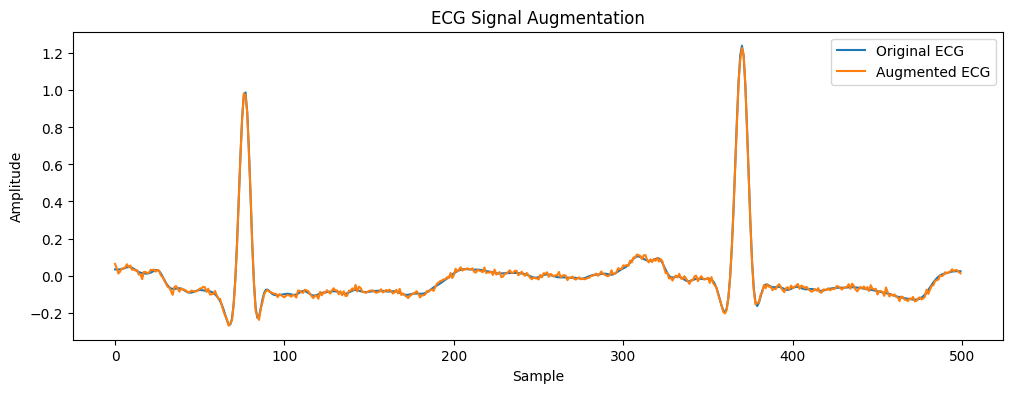

In [134]:


plt.figure(figsize=(12, 4))

plt.plot(windows[0], label="Original ECG")
plt.plot(augmented_windows[0], label="Augmented ECG")

plt.title("ECG Signal Augmentation")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.legend()

plt.show()